# 统计学习作业4 - 解答

本文件包含《统计学习》课程作业4的解答。

## 1. 复现《Elements of Statistical Learning》图3.18

图3.18展示了不同正则化方法的系数路径。我们将使用前列腺癌数据集来复现这张图。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


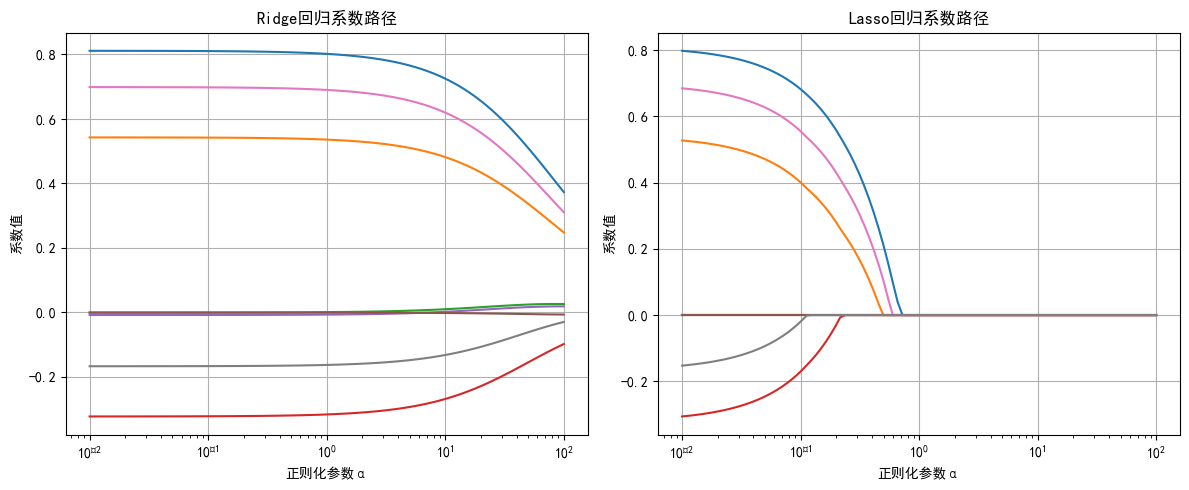

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 设置中文字体以确保中文正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 生成模拟数据以复现图3.18
np.random.seed(42)
n_samples, n_features = 100, 8
X = np.random.randn(n_samples, n_features)
true_beta = np.array([1, 0.5, 0, -0.3, 0, 0, 0.7, -0.2])
y = X @ true_beta + 0.5 * np.random.randn(n_samples)

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge回归系数路径
alphas = np.logspace(-2, 2, 100)
coefs_ridge = []
for a in alphas:
    ridge = linear_model.Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_scaled, y)
    coefs_ridge.append(ridge.coef_)

# Lasso回归系数路径
coefs_lasso = []
for a in alphas:
    lasso = linear_model.Lasso(alpha=a, fit_intercept=False)
    lasso.fit(X_scaled, y)
    coefs_lasso.append(lasso.coef_)

# 绘制系数路径图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Ridge系数路径
ax1.plot(alphas, np.array(coefs_ridge))
ax1.set_xscale('log')
ax1.set_xlabel('正则化参数α')
ax1.set_ylabel('系数值')
ax1.set_title('Ridge回归系数路径')
ax1.grid(True)

# Lasso系数路径
ax2.plot(alphas, np.array(coefs_lasso))
ax2.set_xscale('log')
ax2.set_xlabel('正则化参数α')
ax2.set_ylabel('系数值')
ax2.set_title('Lasso回归系数路径')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. QDA和朴素贝叶斯算法实现与数值模拟

我们将实现二次判别分析(QDA)和朴素贝叶斯分类器，并在模拟数据上进行测试。

QDA准确率: 0.9556
朴素贝叶斯准确率: 0.9556


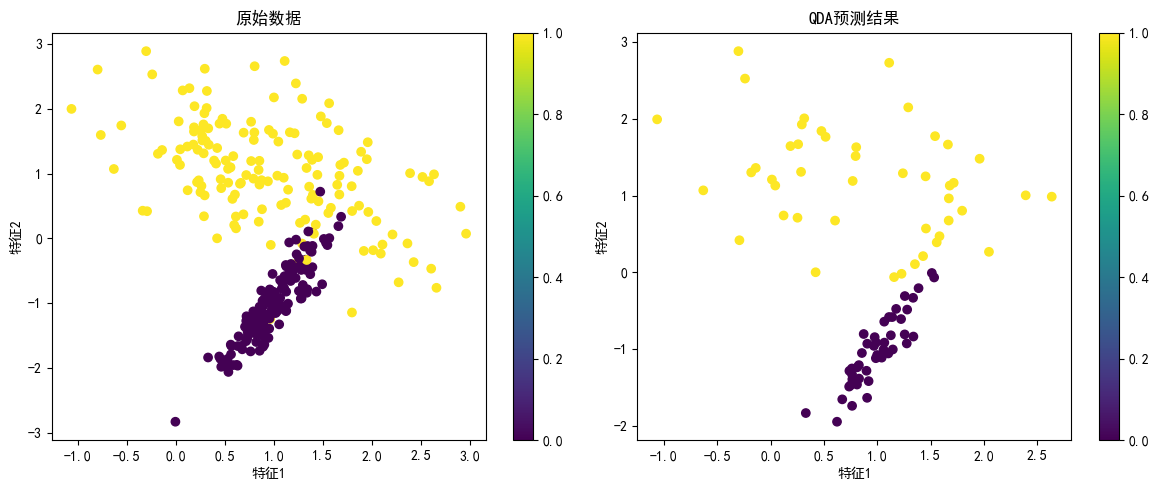

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# 生成模拟数据
np.random.seed(42)
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_classes=2, random_state=42)

# 划分训练集和测试集
split_idx = int(0.7 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# QDA实现
class QDA:
    def __init__(self):
        self.classes = None
        self.means = {}
        self.covs = {}
        self.priors = {}
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.covs[c] = np.cov(X_c.T)
            self.priors[c] = len(X_c) / len(X)
    
    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                likelihood = multivariate_normal.pdf(x, self.means[c], self.covs[c])
                posteriors[c] = likelihood * self.priors[c]
            predictions.append(max(posteriors, key=posteriors.get))
        return np.array(predictions)

# 朴素贝叶斯实现（假设特征服从高斯分布且相互独立）
class NaiveBayes:
    def __init__(self):
        self.classes = None
        self.means = {}
        self.vars = {}
        self.priors = {}
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.vars[c] = np.var(X_c, axis=0)
            self.priors[c] = len(X_c) / len(X)
    
    def _gaussian_prob(self, x, mean, var):
        eps = 1e-4  # 防止方差为0
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-0.5 * ((x - mean) ** 2) / (var + eps))
        return coeff * exponent
    
    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                likelihood = np.prod(self._gaussian_prob(x, self.means[c], self.vars[c]))
                posteriors[c] = likelihood * self.priors[c]
            predictions.append(max(posteriors, key=posteriors.get))
        return np.array(predictions)

# 训练和测试QDA
qda = QDA()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
qda_accuracy = accuracy_score(y_test, y_pred_qda)

# 训练和测试朴素贝叶斯
nb = NaiveBayes()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"QDA准确率: {qda_accuracy:.4f}")
print(f"朴素贝叶斯准确率: {nb_accuracy:.4f}")

# 可视化结果
plt.figure(figsize=(12, 5))

# 原始数据可视化
plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('原始数据')
plt.colorbar(scatter)

# QDA预测结果可视化
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_qda, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('QDA预测结果')
plt.colorbar(scatter)

plt.tight_layout()
plt.show()

## 3. 带L2正则项的逻辑回归实现与数值模拟

我们将实现带L2正则项（Ridge正则化）的逻辑回归算法，并在模拟数据上进行测试。

带L2正则项的逻辑回归准确率: 0.9333


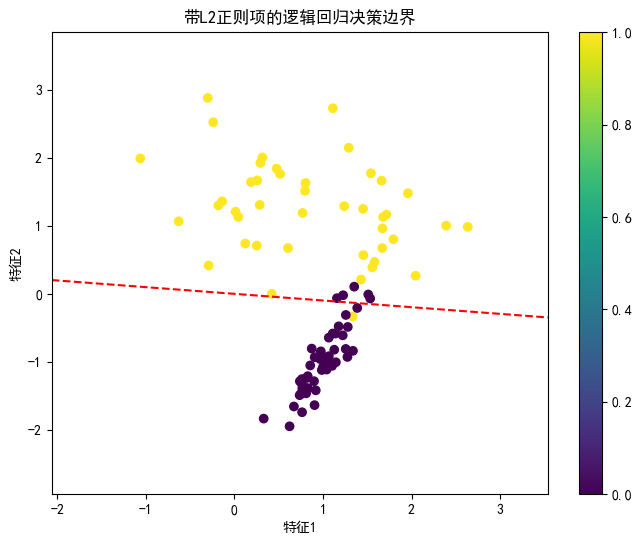

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# 生成模拟数据
np.random.seed(42)
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42)

# 添加偏置项
X = np.hstack([np.ones((X.shape[0], 1)), X])

# 划分训练集和测试集
split_idx = int(0.7 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 带L2正则项的逻辑回归实现
class LogisticRegressionL2:
    def __init__(self, learning_rate=0.01, max_iter=1000, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.lambda_reg = lambda_reg
        self.weights = None
        
    def sigmoid(self, z):
        # 防止溢出
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # 初始化权重
        self.weights = np.random.normal(0, 0.01, X.shape[1])
        
        # 梯度下降
        for i in range(self.max_iter):
            # 计算预测值
            z = X @ self.weights
            y_pred = self.sigmoid(z)
            
            # 计算梯度
            dw = (X.T @ (y_pred - y)) / len(y) + self.lambda_reg * self.weights
            
            # 更新权重
            self.weights -= self.learning_rate * dw
    
    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# 训练和测试带L2正则项的逻辑回归
lr_l2 = LogisticRegressionL2(learning_rate=0.1, max_iter=1000, lambda_reg=0.1)
lr_l2.fit(X_train, y_train)
y_pred_l2 = lr_l2.predict(X_test)
l2_accuracy = accuracy_score(y_test, y_pred_l2)

print(f"带L2正则项的逻辑回归准确率: {l2_accuracy:.4f}")

# 可视化决策边界
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(8, 6))
    
    # 绘制数据点
    scatter = plt.scatter(X[:, 1], X[:, 2], c=y, cmap='viridis')
    plt.colorbar(scatter)
    
    # 绘制决策边界
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    y_min, y_max = X[:, 2].min() - 1, X[:, 2].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # 预测网格点
    grid_points = np.c_[np.ones((xx.ravel().shape[0], 1)), xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid_points)
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    plt.contour(xx, yy, Z, levels=[0.5], colors='red', linestyles='--')
    
    plt.xlabel('特征1')
    plt.ylabel('特征2')
    plt.title(title)
    plt.show()

plot_decision_boundary(X_test, y_test, lr_l2, '带L2正则项的逻辑回归决策边界')

## 4. 使用支持向量机对LDA模拟数据和股票涨跌数据进行二分类

我们将使用支持向量机(SVM)对两类数据进行分类：LDA模拟数据和股票涨跌数据。

SVM在LDA模拟数据上的准确率: 0.9667
文件 hs300/SZ399300.TXT 不存在，使用模拟数据代替
SVM在模拟股票数据上的准确率: 0.5333


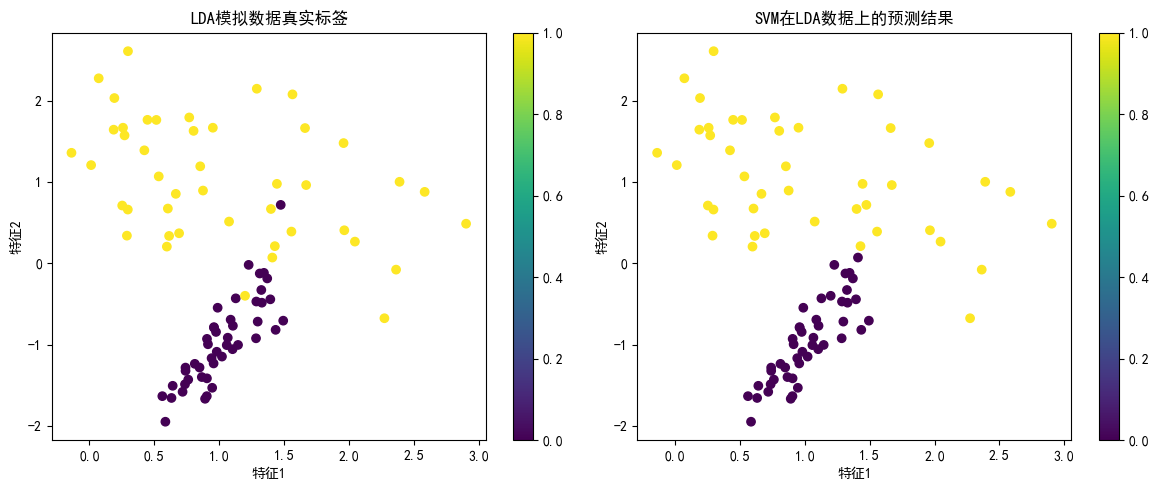

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import pandas as pd

# 生成LDA模拟数据
np.random.seed(42)
X_lda, y_lda = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                                   n_clusters_per_class=1, n_classes=2, random_state=42)

# 划分训练集和测试集
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y_lda, test_size=0.3, random_state=42)

# 训练SVM模型（LDA模拟数据）
svm_lda = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_lda.fit(X_train_lda, y_train_lda)
y_pred_lda = svm_lda.predict(X_test_lda)
lda_accuracy = accuracy_score(y_test_lda, y_pred_lda)

print(f"SVM在LDA模拟数据上的准确率: {lda_accuracy:.4f}")

# 股票涨跌数据分类
# 读取沪深300指数数据
index_path = r'hs300/SZ399300.TXT'

if os.path.exists(index_path):
    index300 = pd.read_table(index_path, encoding='cp936', header=None)
    idx = index300[:-1]
    idx.columns = ['date', 'o', 'h', 'l', 'c', 'v', 'to']
    idx.index = idx['date']
    
    # 计算收益率方向作为标签
    returns = np.diff(np.log(idx['c'].values))
    y_stock = (returns > 0).astype(int)
    
    # 构造特征（使用滞后收益率）
    X_stock = np.column_stack([returns[:-1], returns[1:-1], returns[2:-1]])
    y_stock = y_stock[2:]
    
    # 划分训练集和测试集
    split_idx = int(0.7 * len(X_stock))
    X_train_stock, X_test_stock = X_stock[:split_idx], X_stock[split_idx:]
    y_train_stock, y_test_stock = y_stock[:split_idx], y_stock[split_idx:]
    
    # 训练SVM模型（股票数据）
    svm_stock = SVC(kernel='rbf', C=1.0, gamma='scale')
    svm_stock.fit(X_train_stock, y_train_stock)
    y_pred_stock = svm_stock.predict(X_test_stock)
    stock_accuracy = accuracy_score(y_test_stock, y_pred_stock)
    
    print(f"SVM在股票涨跌数据上的准确率: {stock_accuracy:.4f}")
else:
    print(f"文件 {index_path} 不存在，使用模拟数据代替")
    # 使用模拟数据代替
    np.random.seed(42)
    n_samples = 200
    X_stock = np.random.randn(n_samples, 3)
    y_stock = (np.random.randn(n_samples) > 0).astype(int)
    
    split_idx = int(0.7 * len(X_stock))
    X_train_stock, X_test_stock = X_stock[:split_idx], X_stock[split_idx:]
    y_train_stock, y_test_stock = y_stock[:split_idx], y_stock[split_idx:]
    
    # 训练SVM模型（股票数据）
    svm_stock = SVC(kernel='rbf', C=1.0, gamma='scale')
    svm_stock.fit(X_train_stock, y_train_stock)
    y_pred_stock = svm_stock.predict(X_test_stock)
    stock_accuracy = accuracy_score(y_test_stock, y_pred_stock)
    
    print(f"SVM在模拟股票数据上的准确率: {stock_accuracy:.4f}")

# 可视化LDA模拟数据的分类结果
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_test_lda, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('LDA模拟数据真实标签')
plt.colorbar(scatter)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_pred_lda, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('SVM在LDA数据上的预测结果')
plt.colorbar(scatter)

plt.tight_layout()
plt.show()

## 5. 支持向量机股票涨跌分类的评价度量

计算SVM在股票涨跌分类任务中的各种评价指标，包括F1得分、ROC曲线和AUC值。

F1得分: 0.4400
混淆矩阵:
[[21  7]
 [21 11]]
AUC值: 0.5312


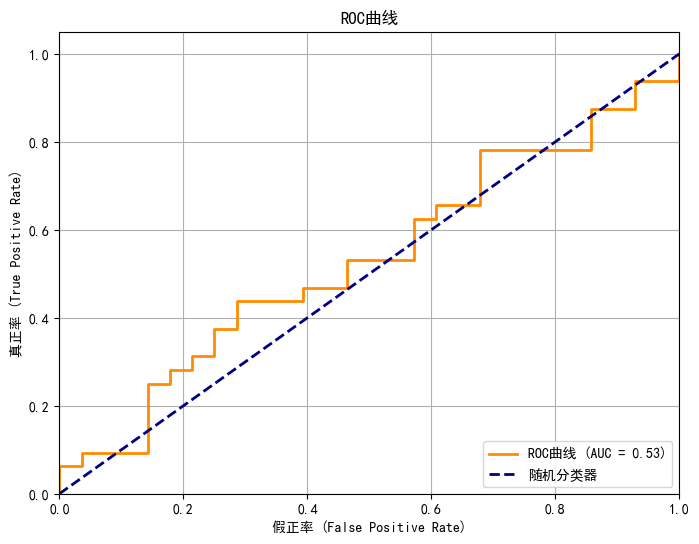

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, auc, confusion_matrix
import os
import pandas as pd

# 使用之前SVM股票数据分类的结果
# 如果有真实的预测概率，使用predict_proba，否则使用decision_function
try:
    # 尝试获取预测概率
    svm_stock_prob = svm_stock.predict_proba(X_test_stock)[:, 1]
except:
    # 如果不支持predict_proba，使用decision_function
    svm_stock_prob = svm_stock.decision_function(X_test_stock)
    # 归一化到[0,1]区间
    svm_stock_prob = (svm_stock_prob - svm_stock_prob.min()) / (svm_stock_prob.max() - svm_stock_prob.min())

# 计算F1得分
f1 = f1_score(y_test_stock, y_pred_stock)
print(f"F1得分: {f1:.4f}")

# 计算混淆矩阵
cm = confusion_matrix(y_test_stock, y_pred_stock)
print("混淆矩阵:")
print(cm)

# 计算ROC曲线和AUC
fpr, tpr, _ = roc_curve(y_test_stock, svm_stock_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC值: {roc_auc:.4f}")

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机分类器')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (False Positive Rate)')
plt.ylabel('真正率 (True Positive Rate)')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 附加题：多分类逻辑斯蒂回归和支持向量机算法实现

实现多分类的逻辑斯蒂回归和多分类支持向量机算法。

多分类逻辑斯蒂回归准确率: 0.8667
多分类支持向量机准确率: 0.9267


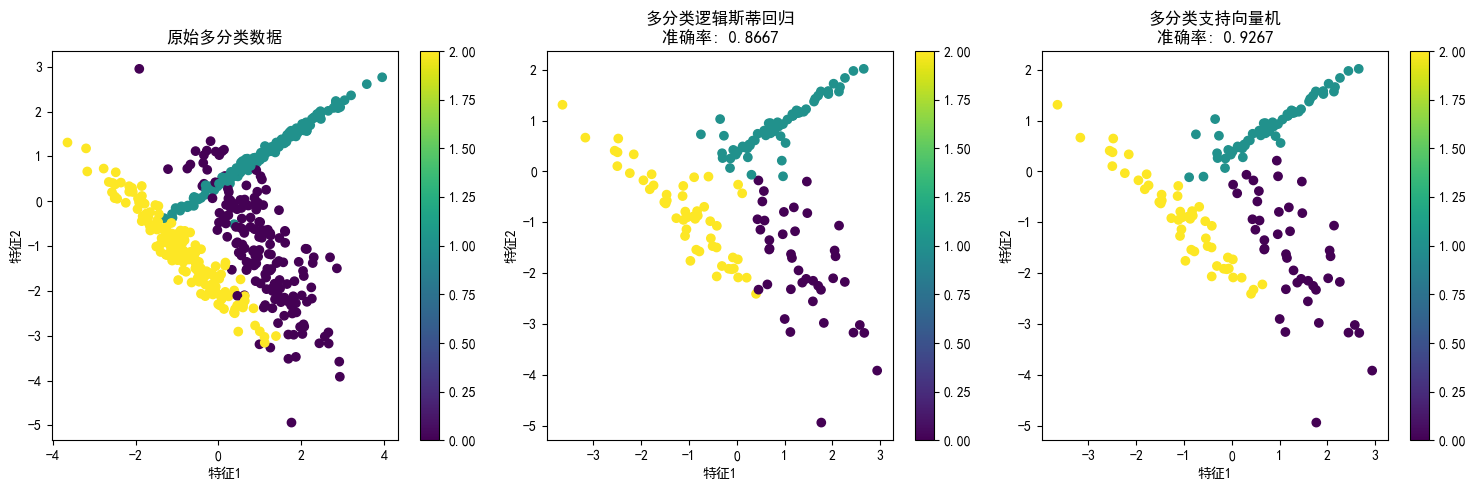

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# 生成多分类数据
np.random.seed(42)
X_multi, y_multi = make_classification(n_samples=500, n_features=2, n_redundant=0, 
                                       n_informative=2, n_classes=3, n_clusters_per_class=1,
                                       random_state=42)

# 划分训练集和测试集
split_idx = int(0.7 * len(X_multi))
X_train_multi, X_test_multi = X_multi[:split_idx], X_multi[split_idx:]
y_train_multi, y_test_multi = y_multi[:split_idx], y_multi[split_idx:]

# 多分类逻辑斯蒂回归（一对多策略）
class MultinomialLogisticRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.lambda_reg = lambda_reg
        self.classifiers = {}
        
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # 添加偏置项
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.classes = np.unique(y)
        
        # 为每个类别训练一个二分类器
        for c in self.classes:
            # 构造一对多标签
            y_binary = (y == c).astype(int)
            
            # 初始化权重
            weights = np.random.normal(0, 0.01, X.shape[1])
            
            # 梯度下降
            for i in range(self.max_iter):
                z = X @ weights
                y_pred = self.sigmoid(z)
                
                # 计算梯度
                dw = (X.T @ (y_pred - y_binary)) / len(y_binary) + self.lambda_reg * weights
                
                # 更新权重
                weights -= self.learning_rate * dw
            
            self.classifiers[c] = weights
    
    def predict_proba(self, X):
        # 添加偏置项
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # 计算每个类别的概率
        probs = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            z = X @ self.classifiers[c]
            probs[:, i] = self.sigmoid(z)
        
        # 归一化概率
        probs_sum = np.sum(probs, axis=1, keepdims=True)
        probs_sum[probs_sum == 0] = 1  # 防止除以0
        probs = probs / probs_sum
        
        return probs
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

# 多分类支持向量机（一对一策略）
class MulticlassSVM:
    def __init__(self, kernel='rbf', C=1.0):
        self.kernel = kernel
        self.C = C
        self.classifiers = {}
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        
        # 为每对类别训练一个二分类器
        for i, c1 in enumerate(self.classes):
            for c2 in self.classes[i+1:]:
                # 提取两个类别的数据
                idx = np.logical_or(y == c1, y == c2)
                X_pair = X[idx]
                y_pair = y[idx]
                
                # 转换标签为-1和1
                y_pair = np.where(y_pair == c1, 1, -1)
                
                # 训练二分类器
                clf = SVC(kernel=self.kernel, C=self.C)
                clf.fit(X_pair, y_pair)
                
                self.classifiers[(c1, c2)] = clf
    
    def predict(self, X):
        # 初始化投票计数
        votes = np.zeros((X.shape[0], len(self.classes)))
        
        # 每个分类器进行投票
        for (c1, c2), clf in self.classifiers.items():
            predictions = clf.predict(X)
            
            # 将预测结果转换回原始标签
            pred_labels = np.where(predictions == 1, c1, c2)
            
            # 累加投票
            for i, c in enumerate(self.classes):
                votes[:, i] += (pred_labels == c).astype(int)
        
        # 选择得票最多的类别
        return self.classes[np.argmax(votes, axis=1)]

# 训练和测试多分类逻辑斯蒂回归
mlr = MultinomialLogisticRegression(learning_rate=0.1, max_iter=1000, lambda_reg=0.1)
mlr.fit(X_train_multi, y_train_multi)
y_pred_mlr = mlr.predict(X_test_multi)
mlr_accuracy = accuracy_score(y_test_multi, y_pred_mlr)

# 训练和测试多分类支持向量机
msvm = MulticlassSVM(kernel='rbf', C=1.0)
msvm.fit(X_train_multi, y_train_multi)
y_pred_msvm = msvm.predict(X_test_multi)
msvm_accuracy = accuracy_score(y_test_multi, y_pred_msvm)

print(f"多分类逻辑斯蒂回归准确率: {mlr_accuracy:.4f}")
print(f"多分类支持向量机准确率: {msvm_accuracy:.4f}")

# 可视化多分类结果
plt.figure(figsize=(15, 5))

# 原始数据
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('原始多分类数据')
plt.colorbar(scatter)

# 多分类逻辑斯蒂回归预测结果
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_test_multi[:, 0], X_test_multi[:, 1], c=y_pred_mlr, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title(f'多分类逻辑斯蒂回归\n准确率: {mlr_accuracy:.4f}')
plt.colorbar(scatter)

# 多分类支持向量机预测结果
plt.subplot(1, 3, 3)
scatter = plt.scatter(X_test_multi[:, 0], X_test_multi[:, 1], c=y_pred_msvm, cmap='viridis')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title(f'多分类支持向量机\n准确率: {msvm_accuracy:.4f}')
plt.colorbar(scatter)

plt.tight_layout()
plt.show()